## Credit Card EDA

In this section we are going to perform the EDA to get to know the data and start cleaning and preprocessing information.

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('C:/Users/mad52/fraud-detection-api/creditcard.csv')

#printing the shape, columns, data types and null values of the dataset
print('Shape:',df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData type:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data type:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Null values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


After this first block we cann see that:

* There aren't any null values in any column.
* The name of the some columns is not descriptive and doesn't give us any additional information.
* Column type is float for all fo the columns

### Class balance

In the next section we are going to review the class imbalance, this is important because it is goint to affect how the model is going to be trained, and the extra steps we need to take to balance the classes in order to have good quality training data.

Count:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
 Class
0    99.83
1     0.17
Name: proportion, dtype: float64


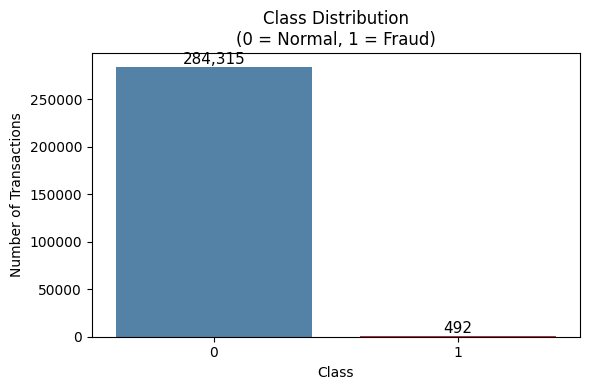

In [3]:
#defining the target variable and checking the class distribution
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("Count:\n", fraud_counts)
print("\nPercentage:\n", fraud_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Class', hue='Class', legend=False, data=df, palette=['steelblue', 'crimson'], ax=ax)
ax.set_title('Class Distribution\n(0 = Normal, 1 = Fraud)')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Transactions')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../class_distribution.png', dpi=150)
plt.show()

After this small analysis we can see that there is a very high class imbalance in the dataset(99.8 vs 0.17) this means that we need to balance the classes in the preprocessing section or model training parameters.

### Transaction Amount Distribution

In the following section we are going to try to visually compare how a fraudulent and regular transaction look just considering the transaction amount.

We are going to use a log scale to have a better perspective because transaction amounts are very different and have extreme outliers and using a regular scale is not going to help a side by side comparison.

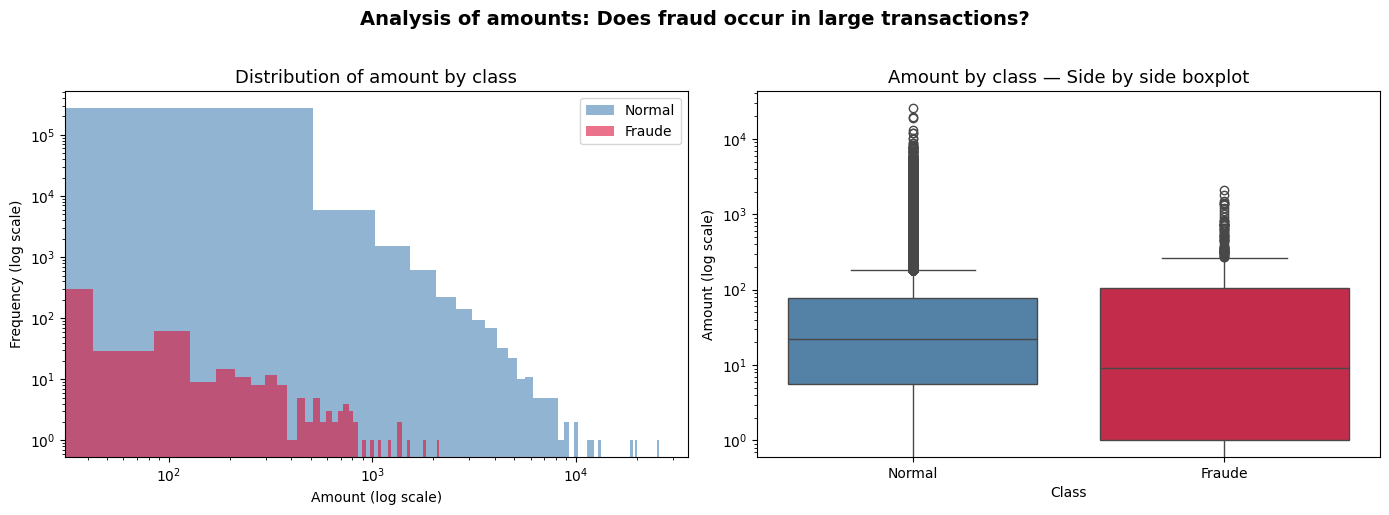

          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram with log scale ---
for clase, color, label in zip([0, 1],
                                ['steelblue', 'crimson'],
                                ['Normal', 'Fraude']):
    subset = df[df['Class'] == clase]['Amount']
    axes[0].hist(subset, bins=50, alpha=0.6,
                 color=color, label=label)

axes[0].set_title('Distribution of amount by class', fontsize=13)
axes[0].set_xlabel('Amount (log scale)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()

# --- Side by side boxplot comparison ---
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class'] = df_plot['Class'].map({0: 'Normal', 1: 'Fraude'})

sns.boxplot(x='Class', y='Amount', data=df_plot,
            hue='Class', legend=False,
            palette=['steelblue', 'crimson'], ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Amount by class — Side by side boxplot', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Amount (log scale)')

plt.suptitle('Analysis of amounts: Does fraud occur in large transactions?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('Class')['Amount'].describe().round(2))

Insights:

We can see that fraudlent transaction amounts are concentrated towards the low side, with a maximum of 2123.87 . The normal transactions maximum can reach 25,691.16.

This means that scammers use low amount transactions to aovid raising any suspicion. To detect fraud we need more than the transaction amount but what we have found is very relevant specially if we mix it with other features.

### Timestamp analysis

In this section we are going to take a look at the "time" column this is an important feature that is going to help us to detect the fraudulent transactions.

The time columns represents the seconds that passed from the first transaction not a real hour or the day, however we can still use it to extract patterns.

This dataset is composed by 48 hrs of transactions we can use this info to transform the column time into hours to have a more intuitive visualization.

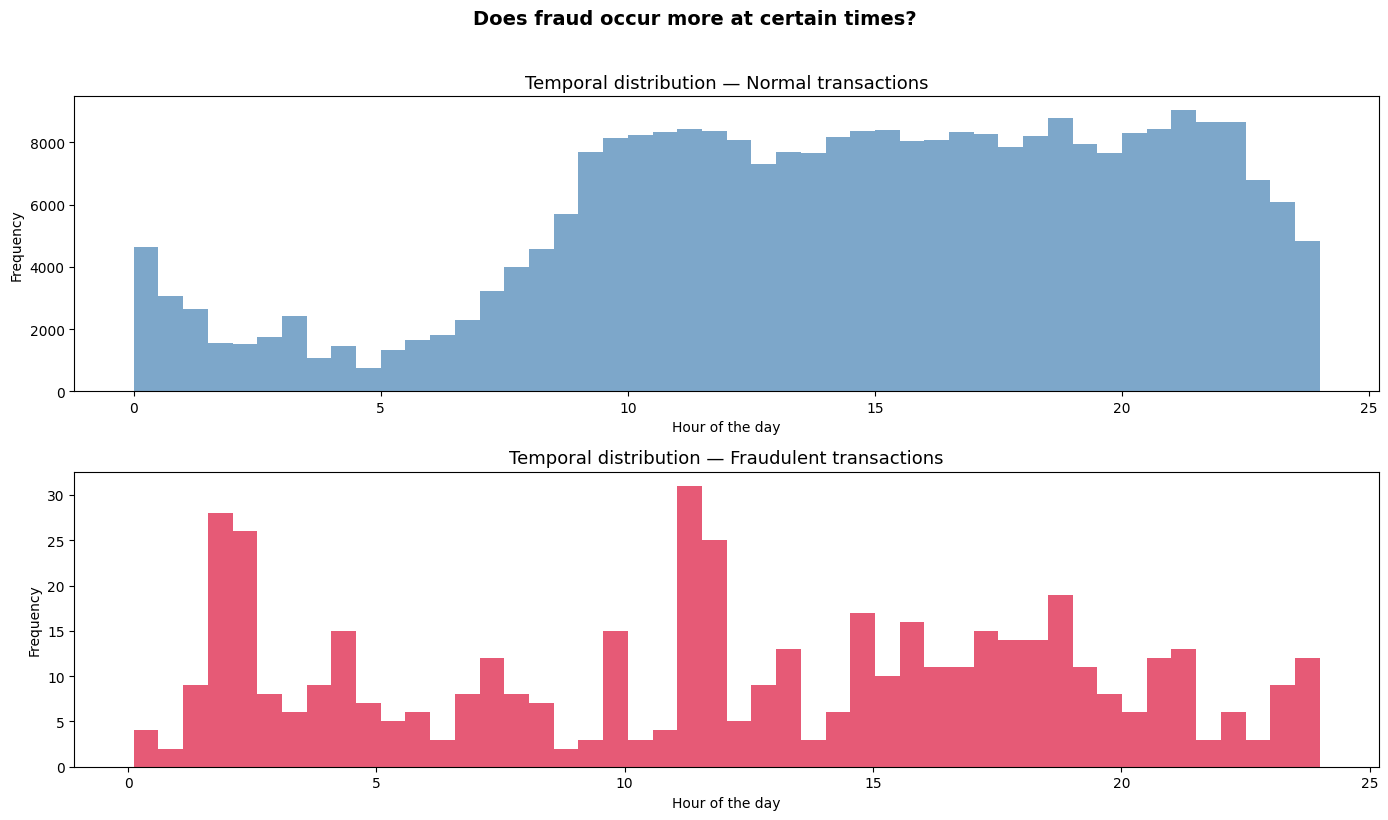

In [5]:
# Converting seconds to hours
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Normal transactions
axes[0].hist(df[df['Class'] == 0]['Hour'], bins=48,
             color='steelblue', alpha=0.7)
axes[0].set_title('Temporal distribution — Normal transactions', fontsize=13)
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Hour of the day')

# Fraudulent transactions
axes[1].hist(df[df['Class'] == 1]['Hour'], bins=48,
             color='crimson', alpha=0.7)
axes[1].set_title('Temporal distribution — Fraudulent transactions', fontsize=13)
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Hour of the day')

plt.suptitle('Does fraud occur more at certain times?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Insights

We can see in the image above that normal transactions have a predictable schedule that is aligned with the human behavior where the mayority of the transactions are done during daytime hours. 

Fraudulent transactions are not clustered have a more random behavior showing some spikes during early hours of the day, maybe because scammers are not expecting users monitoring their accounts.

So we can see that time feature will be very useful for fraudulent transaction predictions.

### Other features analysis

We have 28 other features that doesn't have a descriptive title, in the next section we are going to find out wich of this features have more correlation with the target with a simple statistical method.

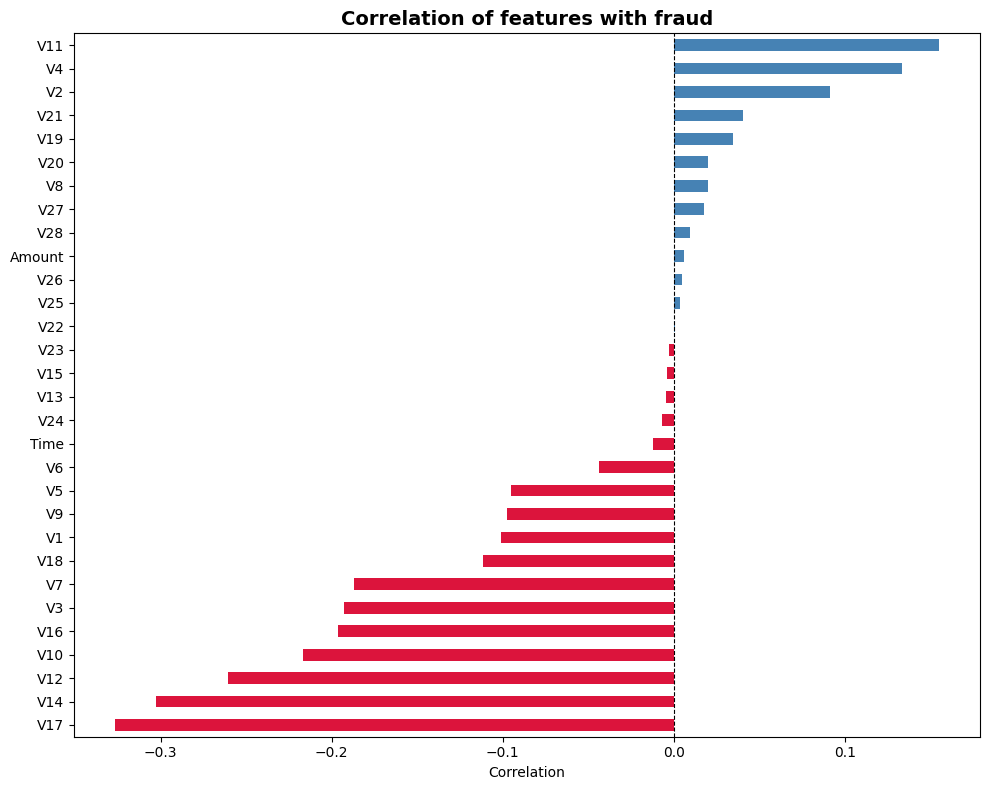

Top 5 with highest positive correlation with fraud:
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549
Name: Class, dtype: float64

Top 5 with highest negative correlation with fraud:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
Name: Class, dtype: float64


In [7]:
# Finding the correlation of features with the target variable
correlations = df.corr()['Class'].drop(['Class', 'Hour']).sort_values()

# Plotting the correlation of features with the target variable
fig, ax = plt.subplots(figsize=(10, 8))

correlations.plot(
    kind='barh',
    color=['crimson' if x < 0 else 'steelblue' for x in correlations],
    ax=ax
)

ax.set_title('Correlation of features with fraud', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features
print("Top 5 with highest positive correlation with fraud:")
print(correlations.tail(5).round(4))
print("\nTop 5 with highest negative correlation with fraud:")
print(correlations.head(5).round(4))

Insight — Feature Correlation

Features V17, V14 y V12 show a higher correlation (negative) with fraud class (-0.33, -0.30, -0.26 respectively) this suggests that low values of this PCA component signals important fraudulent activity.

Positive correlations are weak (maximum 0.09) this suggests that fraud is captured by de negative side of the PCA transformations.

In conclusion we are going to prioritize V17, V14 y V12 and we will keep an eye on them during modeling. We are going to include V1-V28 during the initial training.

Although visual analysis showed that amount and time have son patterns, the statistical analysis showed that the linear correlation is almost null.

This tells us that their predictive singnal is non-linear, models like XGBoost can capture this relations where a simple analysis like df.corr() fails.